In [ ]:
import batsim
import galsim
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

Currently, BATSim only provides two types of non-affine transform, however, the renderer has intentionally been designed to allow users to define and provide their own transforms.

Any user defined transforms should inherit from the base class ``batsim.Transform``. This base class handles backend, data type and centering management. The user defined class should provide a ``_transform_relative()`` method which accepts a ``(2, n)`` array of image coordinates and returns the **inverse transform** of these coordinates.

This is because BATSim uses a backward mapping for its renderer. Given coordinates
$x$ on the regular output-image grid, ``transform(x)`` returns coordinates
$u$ at which the source surface-brightness profile should be evaluated:

$$I_{\rm output}(x) = I_{\rm source}(u)$$

For a locally affine transformation with forward geometric matrix $\textbf{M}$, a source
feature at $u$ appears at

$$x = \textbf{M} \times u.$$

The corresponding BATSim coordinate transform must therefore return

$$u = inv(\textbf{M}) \times x.$$

Although the inverse matrix is used to sample the source profile, visible
features undergo the forward transformation. For example, a source feature
at $u_0$ appears where

$$inv(\textbf{M}) \times x = u_0$$

which implies

$$x = \textbf{M} \times u_0.$$

This backward, or pull-based, convention evaluates the source profile once
for every output location and avoids the gaps and overlaps that can occur
when source samples are pushed forwards onto an output grid.

## Custom Transform Example: Pinwheel Transform

In order to illustrate how users should define custom transforms, we are going to define a non-affine transform class which will turn a centred, circular source into a pinwheel with radially dependent rotation of its isophotes.

In [2]:
# As mentioned previously, a transform object is provided in the form of a Python class
class PinwheelTransform(batsim.Transform): # inherit backend methods from base class
    """
    Apply a rotating, radius-dependent shear to produce twisted isophotes.

    Parameters
    ----------
    radius : float
        Characteristic radius at which the shear reaches ``g_max``.
    g_max : float, optional
        Maximum reduced-shear amplitude. Must satisfy ``0 <= g_max < 1``.
    turns : float, optional
        Number of half-turns made by the shear position angle over one
        characteristic radius. For example, ``turns=0.5`` rotates the
        orientation by 90 degrees between ``r=0`` and ``r=radius``.
    phi0 : float, optional
        Shear position angle at the centre, in radians.
    **kwargs
        Arguments forwarded to :class:`batsim.BaseTransform`.
    """

    # Inititalise with fixed transform parameters
    def __init__( 
        self,
        radius,
        g_max=0.35,
        turns=0.5,
        phi0=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)

        if radius <= 0:
            raise ValueError("radius must be positive.")

        if not 0 <= g_max < 1:
            raise ValueError("g_max must satisfy 0 <= g_max < 1.")

        self.radius = radius
        self.g_max = g_max
        self.turns = turns
        self.phi0 = phi0

    # This is the heart of the transform object, which computes the
    # INVERSE mapped coordinates to be sampled onto the image grid
    # by BATSim. It should accept an array of coordinates, a backend,
    # and a datatype
    def _transform_relative(self, coords, xp, dtype):
        x_output, y_output = coords

        # Technically a backend and datatype does not need to be passed,
        # but if the backend and dtype are hard coded, the same backend
        # and dtype MUST be specified in simulate_galaxy()
        radius = xp.asarray(self.radius, dtype=dtype)
        g_max = xp.asarray(self.g_max, dtype=dtype)
        turns = xp.asarray(self.turns, dtype=dtype)
        phi0 = xp.asarray(self.phi0, dtype=dtype)

        r = xp.sqrt(x_output**2 + y_output**2)
        radial_ratio = r / radius

        # Smoothly increase from zero at the centre, reach g_max at
        # r=radius, and decay again at large radius.
        g_abs = (
            g_max
            * radial_ratio
            * xp.exp(1.0 - radial_ratio)
        )

        # Rotate the local shear position angle with radius.
        phi = phi0 + turns * xp.pi * radial_ratio

        g1 = g_abs * xp.cos(2.0 * phi)
        g2 = g_abs * xp.sin(2.0 * phi)

        # Backward mapping through the inverse local shear matrix.
        inv_norm = xp.sqrt(1.0 - g1**2 - g2**2)

        x_prime = (
            (1.0 - g1) * x_output - g2 * y_output
        ) / inv_norm

        y_prime = (
            -g2 * x_output + (1.0 + g1) * y_output
        ) / inv_norm

        return xp.stack([x_prime, y_prime], axis=0)

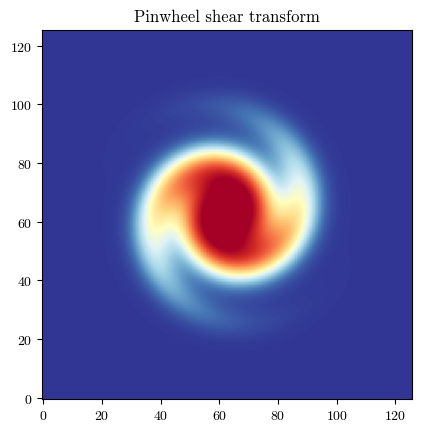

In [ ]:
# Instantiate a simple galaxy profile and PSF with Galsim
gal = galsim.Gaussian(sigma=1.0)
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# Instantiate our custom transform object
pinwheel_transform = PinwheelTransform(
    radius=2.0,
    g_max=0.35,
    turns=0.8,
    phi0=0.0
)

# Call the BATSim renderer to draw the image
gal_pinwheeled = batsim.simulate_galaxy(
    gal_obj=gal,
    scale=0.1,
    transform_obj=pinwheel_transform, # pass our custom class
    psf_obj=psf
)

# Call BATSim plotting utility to get a nicely normalised image
fig = batsim.pltutil.make_plot_image(gal_pinwheeled)
plt.title("Pinwheel shear transform")
plt.savefig("pinwheel_shear_example.pdf", dpi=300)